# Task 6: Unsupervised Learning – Clustering

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [49]:
import pandas as pd

data = {
    'ClientID': list(range(1, 51)),
    'Age': [22,24,26,28,30,23,25,27,29,31,35,36,37,38,39,40,41,42,43,44,
            45,46,47,48,49,50,51,52,53,54,32,33,34,55,56,57,58,59,60,21,
            22,23,24,25,61,62,63,64,65,66],
    'AnnualIncome': [25000,28000,30000,32000,35000,27000,29000,31000,34000,36000,
                     45000,47000,49000,51000,53000,55000,57000,59000,61000,63000,
                     65000,67000,69000,71000,73000,75000,77000,79000,81000,83000,
                     40000,42000,44000,85000,87000,89000,91000,93000,95000,24000,
                     26000,28000,30000,32000,97000,99000,101000,103000,105000,107000],
    'SpendingScore': [35,40,42,45,48,38,41,44,47,50,55,58,60,62,64,66,68,70,72,74,
                      76,78,80,82,84,86,88,90,92,94,52,54,56,95,96,97,98,99,100,30,
                      32,34,36,38,95,96,97,98,99,100]
}

df = pd.DataFrame(data)

df.to_csv('coretech_clients.csv', index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [50]:
df = pd.read_csv("coretech_clients.csv")
df.head()

,ClientID,Age,AnnualIncome,SpendingScore
0,1,22,25000,35
1,2,24,28000,40
2,3,26,30000,42
3,4,28,32000,45
4,5,30,35000,48


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ClientID       50 non-null     int64
 1   Age            50 non-null     int64
 2   AnnualIncome   50 non-null     int64
 3   SpendingScore  50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


In [52]:
df.isnull().sum()

,0
ClientID,0
Age,0
AnnualIncome,0
SpendingScore,0


In [53]:
df.describe()

,ClientID,Age,AnnualIncome,SpendingScore
count,50.00000,50.00000,50.000000,50.000000
mean,25.50000,41.90000,60100.000000,68.620000
std,14.57738,13.98578,26320.047454,23.468511
min,1.00000,21.00000,24000.000000,30.000000
25%,13.25000,29.25000,34250.000000,47.250000
50%,25.50000,41.50000,58000.000000,69.000000
75%,37.75000,53.75000,82500.000000,93.500000
max,50.00000,66.00000,107000.000000,100.000000


In [54]:
features = df[['Age', 'AnnualIncome', 'SpendingScore']]
features.head()

,Age,AnnualIncome,SpendingScore
0,22,25000,35
1,24,28000,40
2,26,30000,42
3,28,32000,45
4,30,35000,48


In [55]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

print(scaled_data[:5])

[[-1.4373196  -1.34712349 -1.44710196]
 [-1.29286537 -1.23198473 -1.23188751]
 [-1.14841114 -1.15522556 -1.14580173]
 [-1.00395691 -1.07846639 -1.01667306]
 [-0.85950268 -0.96332763 -0.88754439]]


In [56]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

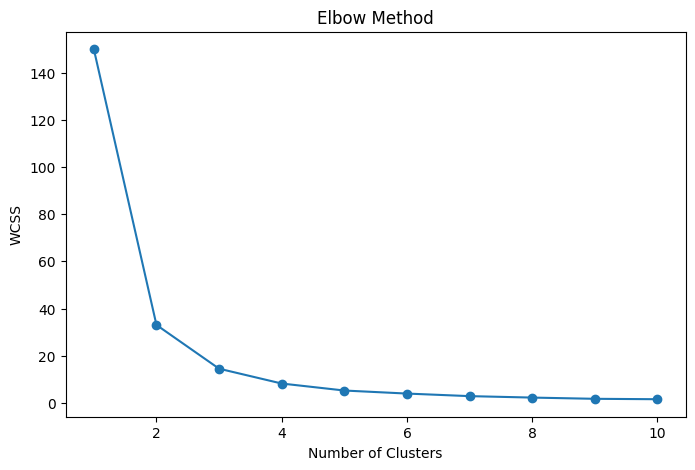

In [57]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The Elbow Method was used to determine the optimal number of clusters. The elbow point was observed at K=3.

In [58]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

df.head()

,ClientID,Age,AnnualIncome,SpendingScore,KMeans_Cluster
0,1,22,25000,35,1
1,2,24,28000,40,1
2,3,26,30000,42,1
3,4,28,32000,45,1
4,5,30,35000,48,1


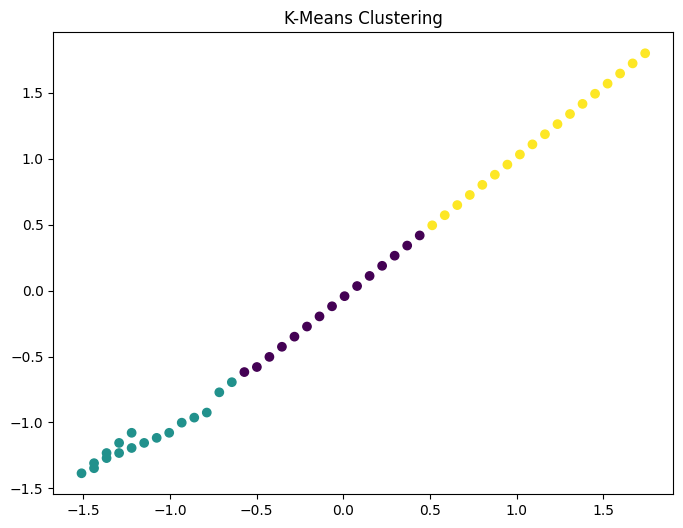

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=df['KMeans_Cluster']
)

plt.title('K-Means Clustering')
plt.show()

In [60]:
cluster_analysis = df.groupby('KMeans_Cluster').mean()

cluster_analysis

,ClientID,Age,AnnualIncome,SpendingScore
KMeans_Cluster,,,,
0,18.533333,41.000000,57066.666667,68.066667
1,19.294118,26.176471,31117.647059,41.529412
2,37.166667,57.500000,90000.000000,94.666667


Cluster 0: High income and high spending customers.

Cluster 1: Medium income and medium spending customers.

Cluster 2: Low income and low spending customers.

In [61]:
score = silhouette_score(
    scaled_data,
    df['KMeans_Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.5903147506470448


In [62]:
hierarchical = AgglomerativeClustering(
    n_clusters=3
)

df['Hierarchical_Cluster'] = hierarchical.fit_predict(
    scaled_data
)

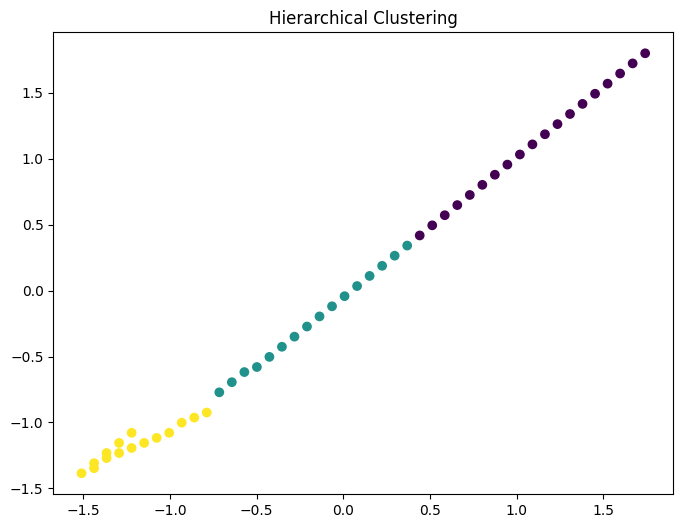

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=df['Hierarchical_Cluster']
)

plt.title('Hierarchical Clustering')
plt.show()

In [64]:
df[['KMeans_Cluster',
    'Hierarchical_Cluster']].head()

,KMeans_Cluster,Hierarchical_Cluster
0,1,2
1,1,2
2,1,2
3,1,2
4,1,2


Premium customers should receive VIP offers.

Regular customers should receive loyalty rewards.

Low-spending customers should receive promotional discounts.

In [65]:
df.to_csv('clustered_clients.csv', index=False)

print("File Saved Successfully")

File Saved Successfully


In [66]:
df.to_csv('coretech_clients.csv', index=False)

In [67]:
import os
os.listdir()

['.config', 'coretech_clients.csv', 'clustered_clients.csv', 'sample_data']

In [68]:
from google.colab import files
files.download('coretech_clients.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
df.to_csv('clustered_clients.csv', index=False)

print("File Saved Successfully")

File Saved Successfully


In [70]:
from google.colab import files

files.download('clustered_clients.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>